# AI-Dostar: обучение спроса на вашем CPU
Это исполняемый разбор настоящего `app/ml/model.py`. Данные — подготовленные
адаптерами выгрузки IEK и Systeme Electric из `data/clean`, без генератора mock.
Источник ноутбука — этот `.py`; `scripts/run_ml_notebook.py` собирает `.ipynb`,
выполняет все ячейки и сохраняет HTML и графики. Повторный запуск обновляет отчёты.
#
**Учитель** — исторический целевой объём продаж `y`. **Ученик** — ансамбль
деревьев. Человек задаёт признаки, функцию ошибки и временной срез; scikit-learn
подбирает разбиения и численные поправки. Отдельного ИИ-учителя здесь нет.
Jupyter — интерфейс запуска Python по ячейкам, а не обязательный движок обучения.
Gym/Gymnasium — среды действий и наград для reinforcement learning. В этом
проекте supervised regression: пары «история → будущие продажи», поэтому Gym нет.
См. [Gymnasium](https://gymnasium.farama.org/introduction/basic_usage/) и
[HistGradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html).

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import sys
import time
from datetime import datetime, timezone

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import sklearn
from IPython.display import Image, display
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error
from threadpoolctl import threadpool_limits, threadpool_info

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "app/ml/model.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from app.adapters import load_clean
from app.ml.model import (FEATURES, MODEL_PATH, data_fingerprint, fit_model,
                          load_model, predict, scores, training_panel)

OUT = ROOT / "docs/assets/ml"
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.facecolor": "white", "savefig.facecolor": "white"})
BLUE, ORANGE, GREEN = "#2563eb", "#e87924", "#059669"

def show_plot(fig, name):
    fig.savefig(OUT / f"{name}.png", dpi=145, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(OUT / f"{name}.png")))

def measured_fit(frame):
    process = psutil.Process()
    before = process.cpu_times()
    start = time.perf_counter()
    fitted = fit_model(frame)
    wall = time.perf_counter() - start
    after = process.cpu_times()
    return fitted, {"wall_seconds": wall,
                    "process_cpu_seconds": after.user + after.system - before.user - before.system,
                    "rss_after_mb": process.memory_info().rss / 1024**2,
                    "rows": int(frame.observable.sum()), "thread_limit": 4}

print("Python", platform.python_version(), "| sklearn", sklearn.__version__)
print("CPU:", platform.processor(), "| logical CPUs:", psutil.cpu_count())
print("Features:", len(FEATURES), FEATURES)

Python 3.14.0 | sklearn 1.9.1
CPU: Intel64 Family 6 Model 186 Stepping 3, GenuineIntel | logical CPUs: 12
Features: 19 ['supplier', 'category', 'unit', 'log_scale', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'mean_3', 'mean_6', 'nonzero_12', 'cv_12', 'baseline_ratio', 'seasonal_index', 'trend_factor', 'month_sin', 'month_cos', 'lead']


## 1. Настоящие данные и признаки
Каждая строка обучения — товар, момент прогноза и горизонт 1–3 месяца.
`X` содержит 19 признаков: поставщика/категорию/единицу, прошлые продажи,
средние, сезонность, тренд, месяц и горизонт. `y = actual / scale`.
`scale` — среднее регулярных продаж за прошлые 12 месяцев, минимум 1.
#
Цель `actual` — продажи из накладных за целевой месяц минус разовый избыток.
Это приближение регулярного спроса, а не известный истинный неудовлетворённый спрос.
Для целей обучения берутся месяцы с положительным начальным остатком.
Подготовка истории пересчитывается отдельно для каждого прошлого среза.

In [2]:
start = time.perf_counter()
data = load_clean()
fingerprint_before = data_fingerprint()
display(pd.DataFrame({"table": list(data), "rows": [len(v) for v in data.values()]}))
panel, last = training_panel(data)
preparation_seconds = time.perf_counter() - start
display(panel.loc[panel.observable, ["supplier", "sku", "origin", "target_month",
                                    "lag_1", "mean_3", "scale", "actual"]].head(8))
print("Observable training examples:", int(panel.observable.sum()), "| last target:", last)
print("Data preparation seconds:", round(preparation_seconds, 3))

,table,rows
0,sales_lines,248875
1,monthly_sales,99561
2,stock_monthly,117282
3,stock_now,3577
4,in_transit,313
5,products,3667
6,seasonality,24
7,manager_baseline,497


Causal history through 2025-06


Causal history through 2025-07


Causal history through 2025-08


Causal history through 2025-09


...

Causal history through 2026-06


Causal history through 2026-07


Causal history through 2026-08


,supplier,sku,origin,target_month,lag_1,mean_3,scale,actual
0,IEK,010300001_,2025-06,2025-07,0.000000,1.988024,6.958333,2.0
1,IEK,010300002_,2025-06,2025-07,1.282077,1.835247,166.916667,185.0
2,IEK,010300003_,2025-06,2025-07,2.286837,1.886051,42.416667,19.0
3,IEK,010300004_,2025-06,2025-07,3.461538,1.461538,4.333333,3.0
4,IEK,010300005_,2025-06,2025-07,3.870968,1.709677,10.333333,5.0
5,IEK,010300006_,2025-06,2025-07,3.260870,2.913043,7.666667,9.0
7,IEK,010300008_,2025-06,2025-07,2.618182,1.454545,9.166667,14.0
8,IEK,010300009_,2025-06,2025-07,1.043478,2.156522,9.583333,41.0


Observable training examples: 86094 | last target: 2026-08
Data preparation seconds: 56.907


## 2. Обучаем до мая, проверяем на июне–августе
Случайного перемешивания будущего и прошлого нет. У обучающих примеров целевой
месяц не позже мая 2026; проверочные прогнозы сделаны из мая на 1–3 месяца вперёд.
Проверочный набор уже использовался при разработке: это воспроизводимый
исторический backtest, не совершенно новый внешний эксперимент.
#
`fit_model` создаёт 150 деревьев, максимум по 15 листьев, с шагом 0.05.
Следующее дерево исправляет ошибки суммы предыдущих. `absolute_error` ориентирует
результат на условную медиану, а не гарантированное среднее количество.
Ни GPU, ни GPT API не участвуют в этом вызове. Четыре — лимит вычислительных
потоков библиотек, а не требование постоянно загружать четыре ядра.

In [3]:
origin = "2026-05"
train = panel.loc[panel.target_month.le(origin) & panel.observable].copy()
test = panel.loc[panel.origin.eq(origin) & panel.observable].copy()
assert train.target_month.max() < test.target_month.min()
assert test.target_month.max() <= str(last)
model, fold_timing = measured_fit(train)
test["ml"] = predict(model, test)
fold_scores = scores(test)
print(json.dumps({"train_target_max": train.target_month.max(),
                  "test_target_min": test.target_month.min(),
                  "test_target_max": test.target_month.max(),
                  "fit": fold_timing, "quality": fold_scores}, indent=2))
test[["supplier", "sku", "unit", "origin", "target_month", "scale", "actual",
      "baseline", "ml"]].to_csv(OUT / "holdout_predictions.csv", index=False, encoding="utf-8")

{
  "train_target_max": "2026-05",
  "test_target_min": "2026-06",
  "test_target_max": "2026-08",
  "fit": {
    "wall_seconds": 1.3562822000003507,
    "process_cpu_seconds": 4.6875,
    "rss_after_mb": 367.96484375,
    "rows": 65513,
    "thread_limit": 4
  },
  "quality": {
    "rows": 6840,
    "baseline_scaled_mae": 0.9816763384681463,
    "ml_scaled_mae": 0.8393529820134039,
    "improvement_pct": 14.497991942724253
  }
}


## 3. Как уменьшается ошибка при добавлении деревьев
По горизонтали — число уже добавленных деревьев. По вертикали — средняя
абсолютная ошибка на нормированных количествах, меньше лучше. Синий — обучение,
оранжевый — будущие месяцы, пунктир — статистический прогноз на тех же будущих
строках. Это измерения `staged_predict`, а не нарисованная ожидаемая кривая.
Все прогнозы обрезаются снизу нулём, как в рабочем расчёте.
Ошибка обучения здесь выше проверочной: состав товаров, месяцев и распределение
целей различаются. Эти кривые нельзя трактовать как две одинаковые выборки.

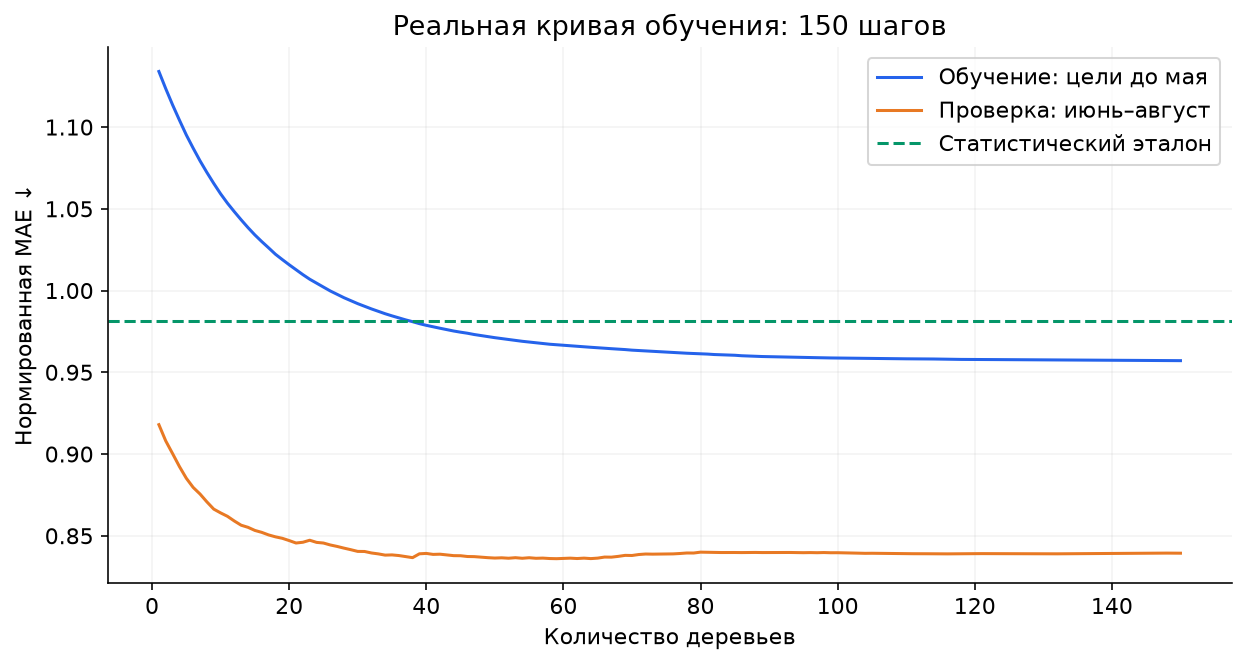

In [4]:
X_train, X_test = train[FEATURES], test[FEATURES]
y_train, y_test = train.actual / train.scale, test.actual / test.scale
curve_rows = []
with threadpool_limits(limits=4):
    for step, (a, b) in enumerate(zip(model.staged_predict(X_train), model.staged_predict(X_test)), 1):
        curve_rows.append({"trees": step,
                           "train_scaled_mae": mean_absolute_error(y_train, np.maximum(a, 0)),
                           "future_scaled_mae": mean_absolute_error(y_test, np.maximum(b, 0))})
curve = pd.DataFrame(curve_rows)
assert np.isclose(curve.iloc[-1].future_scaled_mae, fold_scores["ml_scaled_mae"])
curve.to_csv(OUT / "learning_curve.csv", index=False)
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(curve.trees, curve.train_scaled_mae, color=BLUE, label="Обучение: цели до мая")
ax.plot(curve.trees, curve.future_scaled_mae, color=ORANGE, label="Проверка: июнь–август")
ax.axhline(fold_scores["baseline_scaled_mae"], color=GREEN, ls="--", label="Статистический эталон")
ax.set(xlabel="Количество деревьев", ylabel="Нормированная MAE ↓", title="Реальная кривая обучения: 150 шагов")
ax.legend(); ax.grid(alpha=.15)
show_plot(fig, "learning_curve")

## 4. Какие признаки помогают именно этой модели
Перемешиваем один столбец в проверочных данных и измеряем рост ошибки.
Используем все проверочные строки, 3 повторения, seed=42; усы — стандартное
отклонение между перестановками. Положительное значение означает полезность
признака для этой модели/периода. Нулевое или отрицательное возможно.
Связанные между собой лаги могут заменять друг друга: это не причинный эффект.

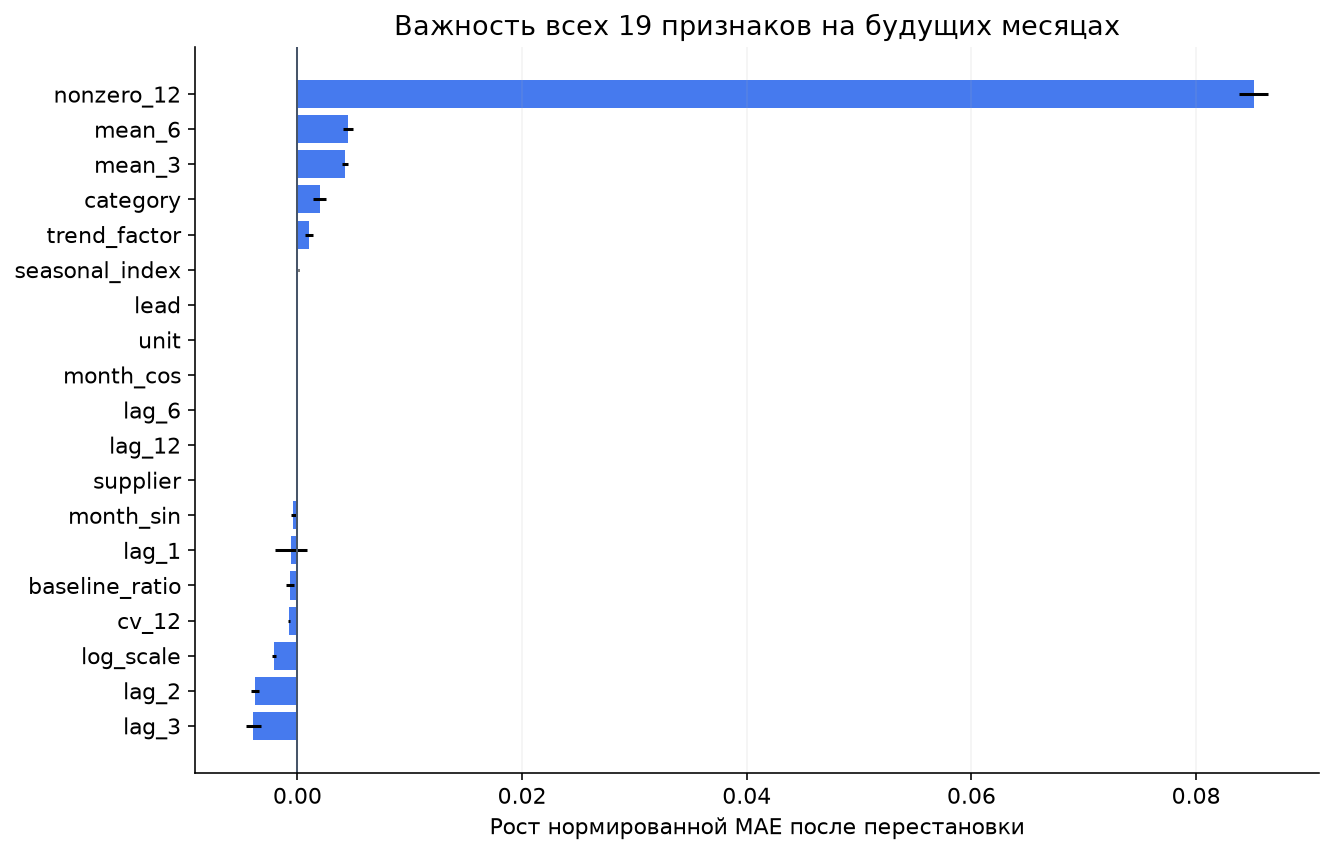

In [5]:
def neg_clipped_mae(estimator, X, y):
    return -mean_absolute_error(y, np.maximum(estimator.predict(X), 0))

with threadpool_limits(limits=4):
    importance = permutation_importance(model, X_test, y_test, n_repeats=3,
                                        random_state=42, n_jobs=1, scoring=neg_clipped_mae)
imp = pd.DataFrame({"feature": FEATURES, "mae_increase": importance.importances_mean,
                    "std": importance.importances_std}).sort_values("mae_increase")
imp.to_csv(OUT / "feature_importance.csv", index=False)
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.barh(imp.feature, imp.mae_increase, xerr=imp["std"], color=BLUE, alpha=.85)
ax.axvline(0, color="#475569", lw=1)
ax.set(xlabel="Рост нормированной MAE после перестановки", title="Важность всех 19 признаков на будущих месяцах")
ax.grid(axis="x", alpha=.15)
show_plot(fig, "feature_importance")

## 5. Прогноз против факта и ошибки
На общей диаграмме количества делятся на свой `scale`, чтобы не суммировать
метры со штуками. Диагональ — идеальный прогноз, каждая точка — реальный пример.
Знак ошибки `прогноз − факт`: ниже нуля означает недопрогноз.
Гистограмма показывает центральные 98% ошибок; число исключённых хвостовых
значений указано в заголовке. Полные значения доступны в CSV без обрезки.

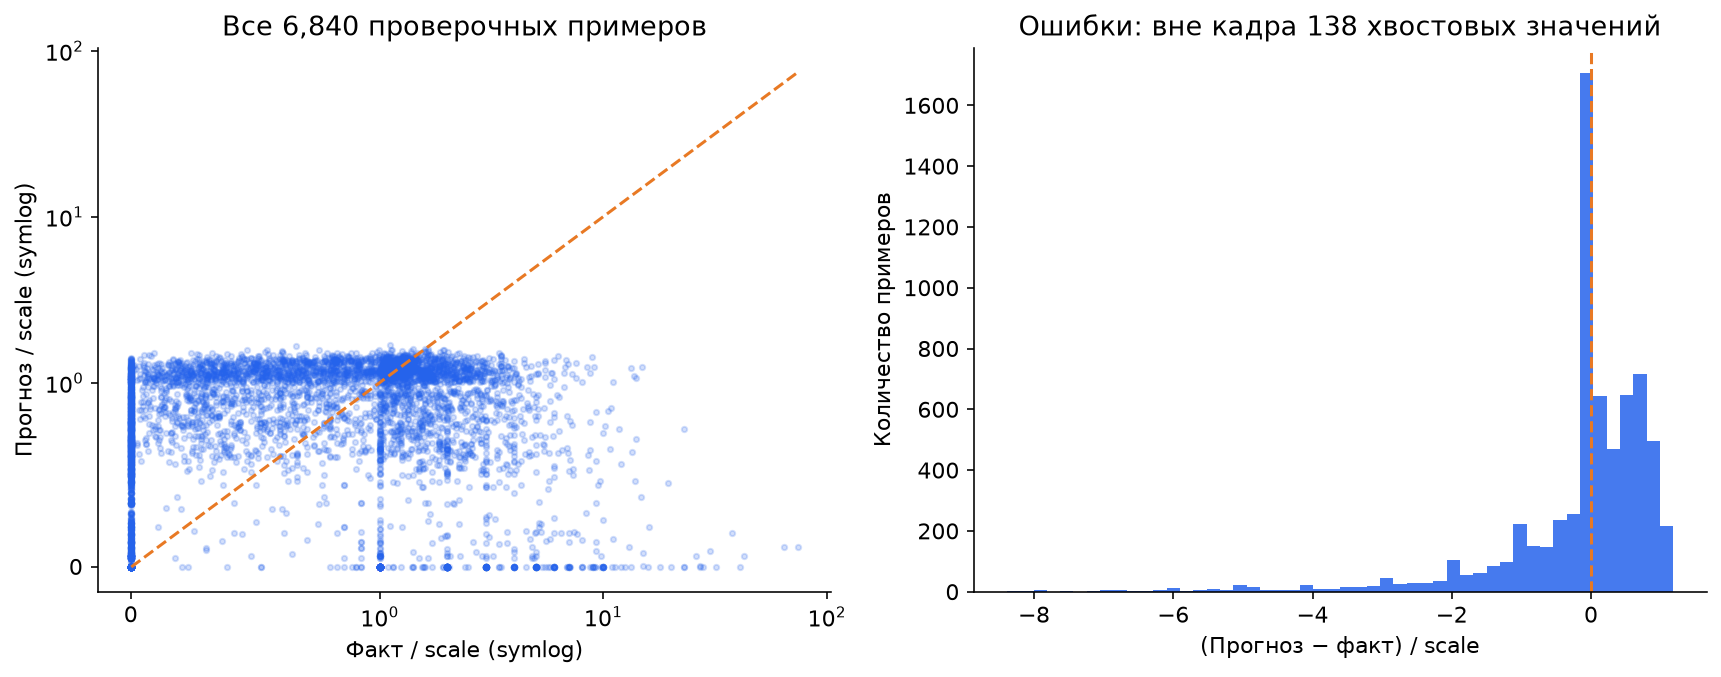

In [6]:
actual_scaled, ml_scaled = test.actual / test.scale, test.ml / test.scale
residual = ml_scaled - actual_scaled
lo, hi = np.quantile(residual, [.01, .99])
central = residual.between(lo, hi)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].scatter(actual_scaled, ml_scaled, s=7, alpha=.2, color=BLUE, rasterized=True)
end = max(actual_scaled.max(), ml_scaled.max())
axes[0].plot([0, end], [0, end], "--", color=ORANGE)
axes[0].set_xscale("symlog", linthresh=1); axes[0].set_yscale("symlog", linthresh=1)
axes[0].set(xlabel="Факт / scale (symlog)", ylabel="Прогноз / scale (symlog)",
            title=f"Все {len(test):,} проверочных примеров")
axes[1].hist(residual[central], bins=50, color=BLUE, alpha=.85)
axes[1].axvline(0, color=ORANGE, ls="--")
axes[1].set(xlabel="(Прогноз − факт) / scale", ylabel="Количество примеров",
            title=f"Ошибки: вне кадра {int((~central).sum())} хвостовых значений")
fig.tight_layout()
show_plot(fig, "residuals")

## 6. Два товара в их собственных единицах
Это заранее выбранные примеры из командного демо, а не подбор лучших результатов:
IEK `130300792_` и SE `030200192_`. Все точки — прогноз из мая на следующие
три месяца. «Факт» означает очищенные от разового избытка наблюдаемые продажи.
Если месяц не проходит фильтр положительного начального остатка, оставляем
пропуск. В частности, август IEK в проверку этого товара не входит.

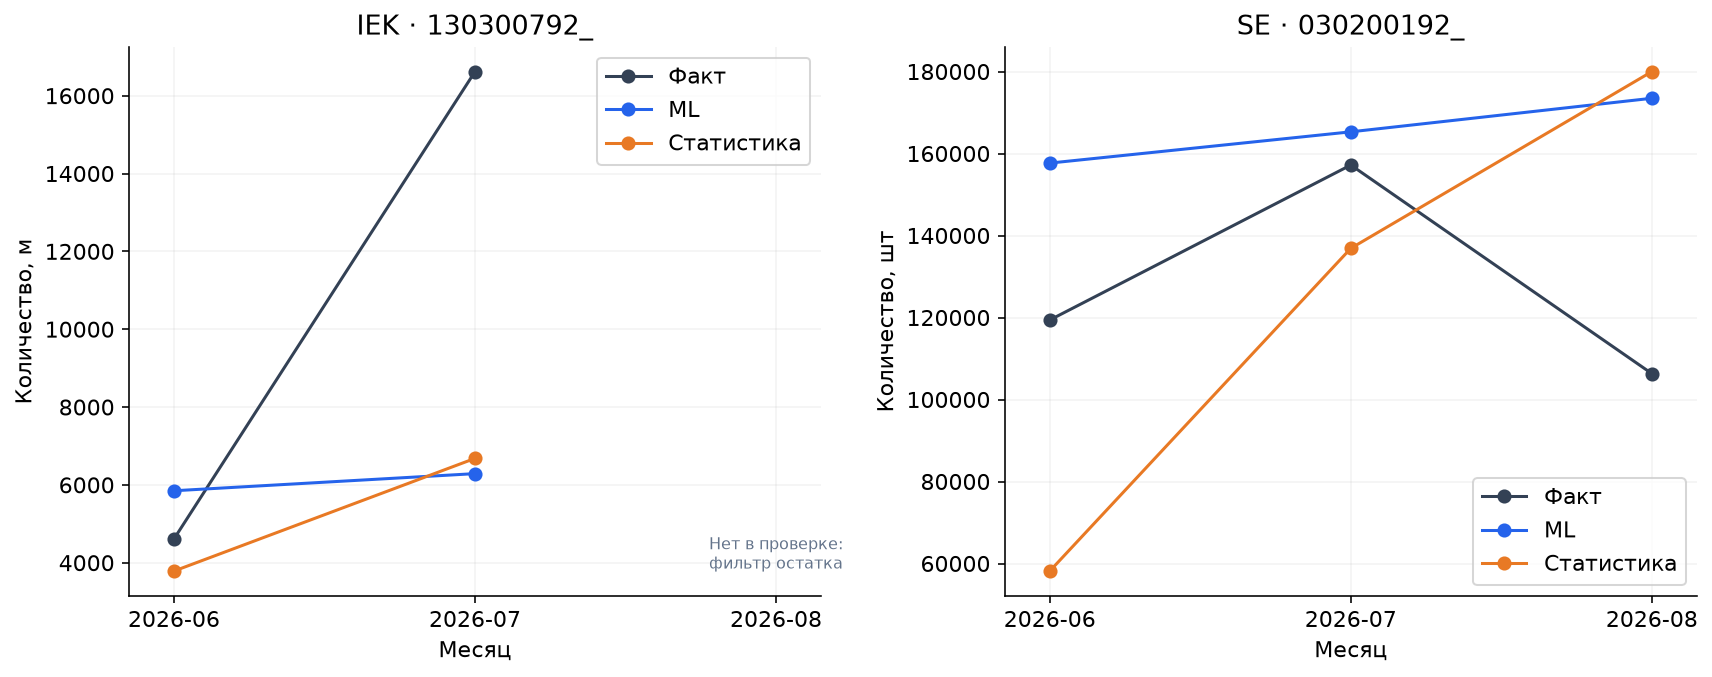

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, supplier, sku in zip(axes, ["IEK", "SE"], ["130300792_", "030200192_"]):
    example = test.loc[test.supplier.eq(supplier) & test.sku.eq(sku)].sort_values("target_month")
    assert len(example) > 0, f"Missing real example: {supplier} {sku}"
    unit = example.unit.iloc[0]
    months = pd.period_range(start=pd.Period(origin, "M") + 1, periods=3, freq="M").astype(str)
    example = example.set_index("target_month").reindex(months)
    for col, label, color in [("actual", "Факт", "#334155"), ("ml", "ML", BLUE),
                               ("baseline", "Статистика", ORANGE)]:
        ax.plot(months, example[col], marker="o", label=label, color=color)
    for month in example.index[example.actual.isna()]:
        ax.text(list(months).index(month), .05, "Нет в проверке:\nфильтр остатка",
                transform=ax.get_xaxis_transform(), ha="center", fontsize=8, color="#64748b")
    ax.set_xticks(range(len(months)), months)
    ax.set_xlim(-.15, len(months) - .85)
    ax.set(title=f"{supplier} · {sku}", xlabel="Месяц", ylabel=f"Количество, {unit}")
    ax.legend(); ax.grid(alpha=.15)
fig.tight_layout()
show_plot(fig, "forecast_examples")

## 7. Повторяем полное обучение и вскрываем сохранённую модель
Теперь отдельно измеряем обучение на всех доступных целевых месяцах по август.
Это новый замер текущего запуска, не восстановленный задним числом старый лог.
Время подготовки данных и время `fit` приводятся отдельно.
CPU-seconds — сумма процессорного времени потоков; она может превышать wall-time.
RSS — память всего процесса после fit, не пиковая память одной модели.
#
Полная модель НЕ используется для оценки на июне–августе: эти месяцы уже были
в её обучении. Рабочий `demand.joblib` не перезаписываем. Проверяем совпадение
прогнозов повторного обучения с сохранённым артефактом на фиксированной выборке.

In [8]:
artifact_sha_before = hashlib.sha256(MODEL_PATH.read_bytes()).hexdigest()
bundle = load_model()
assert bundle["metadata"]["data_sha256"] == fingerprint_before, "Rebuild production model for changed data"
production = bundle["model"]
full_model, full_timing = measured_fit(panel)
comparison = panel.loc[panel.observable].sample(n=min(1000, int(panel.observable.sum())), random_state=42)
np.testing.assert_allclose(predict(full_model, comparison), predict(production, comparison), rtol=1e-10, atol=1e-10)
print("Full fit:", json.dumps(full_timing, indent=2))
print("Saved model SHA256:", artifact_sha_before)
print("Matching predictions on", len(comparison), "fixed examples; artifact unchanged.")

Full fit: {
  "wall_seconds": 1.449057100000573,
  "process_cpu_seconds": 5.4375,
  "rss_after_mb": 403.52734375,
  "rows": 86094,
  "thread_limit": 4
}
Saved model SHA256: 0c925b997bcbd28d94c98e5934301ecd925c6d4a304569a7dbdc2cffa0a7808a
Matching predictions on 1000 fixed examples; artifact unchanged.


## 8. Где ноды: настоящие узлы деревьев
Экспортируем все узлы рабочего артефакта в `production_tree_nodes.csv`.
Это внутренние структуры scikit-learn; их формат привязан к версии библиотеки.
Признаки сопоставляются с реальным порядком после внутреннего преобразования.
Категориальные условия расшифровываются из битовых масок кодировщика.
На картинке — верхние три уровня первого дерева, остальные узлы есть в CSV.
Левый путь соответствует «да», правый — «нет»; пропуски имеют отдельное правило.
Значение листа — добавка к нормированному прогнозу; шаг обучения уже учтён.
Итоговый прогноз складывает стартовое значение и листья всех 150 деревьев,
затем умножается на `scale` и обрезается снизу нулём.

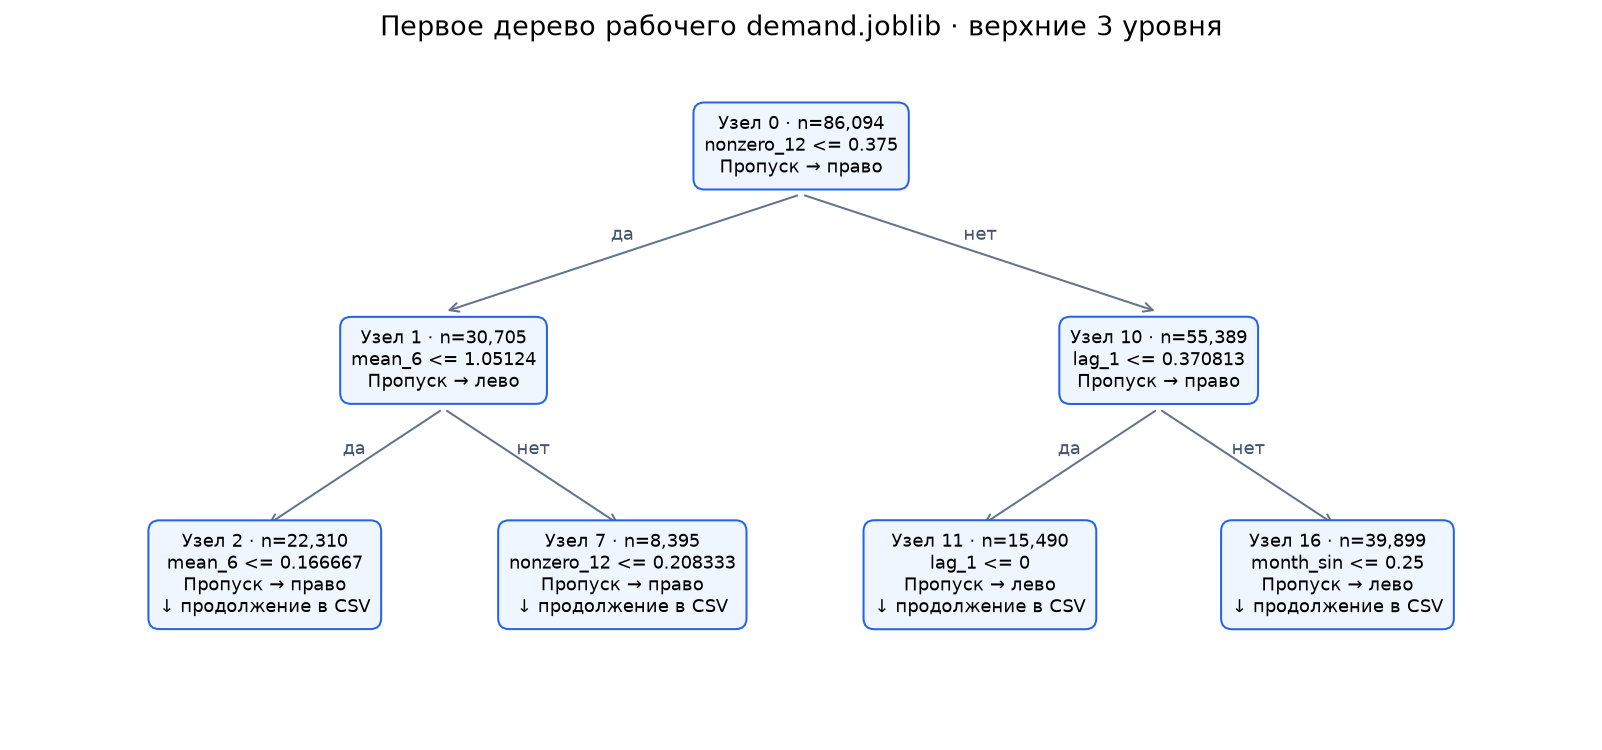

Trees: 150 | nodes: 4350 | leaves: 2250


In [9]:
feature_names = np.asarray(production.feature_names_in_)
internal_names, category_values = [], {}
for name, transformer, selector in production._preprocessor.transformers_:
    if name == "remainder":
        continue
    selected = feature_names[selector].tolist()
    internal_names.extend(selected)
    if name == "encoder":
        category_values.update(zip(selected, transformer.categories_))
assert len(internal_names) == len(FEATURES)

node_rows = []
for tree_id, predictors in enumerate(production._predictors):
    assert len(predictors) == 1
    tree = predictors[0]
    for node_id, node in enumerate(tree.nodes):
        leaf = bool(node["is_leaf"])
        feature = "" if leaf else internal_names[int(node["feature_idx"])]
        cats = []
        if not leaf and node["is_categorical"]:
            bits = tree.raw_left_cat_bitsets[int(node["bitset_idx"])]
            cats = [str(v) for code, v in enumerate(category_values[feature])
                    if int(bits[code // 32]) & (1 << (code % 32))]
        condition = ("leaf" if leaf else
                     f"{feature} in {cats}" if node["is_categorical"] else
                     f"{feature} <= {float(node['num_threshold']):.6g}")
        node_rows.append({"tree": tree_id, "node": node_id, "depth": int(node["depth"]),
                          "count": int(node["count"]), "is_leaf": leaf, "feature": feature,
                          "condition": condition, "left": None if leaf else int(node["left"]),
                          "right": None if leaf else int(node["right"]),
                          "missing_go_to_left": bool(node["missing_go_to_left"]),
                          "value": float(node["value"]),
                          "threshold": None if leaf or node["is_categorical"] else float(node["num_threshold"]),
                          "left_categories": json.dumps(cats, ensure_ascii=False)})
nodes = pd.DataFrame(node_rows)
nodes.to_csv(OUT / "production_tree_nodes.csv", index=False, encoding="utf-8")
first = nodes.loc[nodes.tree.eq(0)].set_index("node")
fig, ax = plt.subplots(figsize=(14, 6))
ax.set(xlim=(-.05, 1.05), ylim=(-.1, 1.15)); ax.axis("off")

def draw_node(node_id, x, y, spread, depth=0):
    node = first.loc[node_id]
    text = f"Узел {node_id} · n={node['count']:,}\n{node.condition}"
    if node.is_leaf:
        text += f"\nДобавка: {node.value:.5f}"
    else:
        text += "\nПропуск → " + ("лево" if node.missing_go_to_left else "право")
        if depth == 2:
            text += "\n↓ продолжение в CSV"
    ax.text(x, y, text, ha="center", va="center", fontsize=9,
            bbox={"boxstyle": "round,pad=.6", "fc": "#eff6ff", "ec": BLUE})
    if not node.is_leaf and depth < 2:
        for child, sign, label in [(int(node.left), -1, "да"), (int(node.right), 1, "нет")]:
            child_x, child_y = x + sign * spread, y - .4
            ax.annotate("", xy=(child_x, child_y + .09), xytext=(x, y - .09),
                        arrowprops={"arrowstyle": "->", "color": "#64748b"})
            ax.text((x + child_x) / 2, (y + child_y) / 2 + .025, label,
                    ha="center", color="#475569", fontsize=9)
            draw_node(child, child_x, child_y, spread / 2, depth + 1)

draw_node(0, .5, 1., .25)
ax.set_title("Первое дерево рабочего demand.joblib · верхние 3 уровня", pad=15)
show_plot(fig, "production_tree")
print("Trees:", len(production._predictors), "| nodes:", len(nodes), "| leaves:", int(nodes.is_leaf.sum()))

## 9. Машиночитаемые доказательства запуска
Сохраняем версии, SHA256 данных/артефакта, границы выборок, время и метрики.
Замеры зависят от процессора и нагрузки. Таблица общего backtest из
`docs/ml-evaluation.json` шире этого ноутбука: три момента прогноза вместо одного.
Улучшение MAE не равно «точности в процентах». В общем backtest у IEK в штуках
WAPE ухудшился — модель не объявляется лучшей для всех товаров и всех метрик.

In [10]:
assert data_fingerprint() == fingerprint_before
assert hashlib.sha256(MODEL_PATH.read_bytes()).hexdigest() == artifact_sha_before
diagnostics = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "python_version": platform.python_version(), "sklearn_version": sklearn.__version__,
    "cpu": platform.processor(), "logical_cpus": psutil.cpu_count(),
    "threadpools": [{k: pool.get(k) for k in ["internal_api", "version", "architecture"]}
                    for pool in threadpool_info()],
    "data_sha256": fingerprint_before, "production_artifact_sha256": artifact_sha_before,
    "source_tables": {name: len(frame) for name, frame in data.items()},
    "features": FEATURES, "preparation_seconds": preparation_seconds,
    "fold": {"origin": origin, "train_target_max": train.target_month.max(),
             "test_target_min": test.target_month.min(), "test_target_max": test.target_month.max(),
             "fit": fold_timing, "metrics": fold_scores},
    "full_fit": full_timing, "full_training_target_max": str(last),
    "production_trees": len(production._predictors), "production_nodes": len(nodes),
    "production_leaves": int(nodes.is_leaf.sum()), "replication_examples": len(comparison),
    "permutation_repeats": 3, "permutation_rows": len(test),
    "caveat": "Historical backtest already inspected during development; not an untouched external test."
}
(OUT / "diagnostics.json").write_text(json.dumps(diagnostics, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
summary = f"""# Замер реального запуска

Сформирован ноутбуком: {diagnostics['created_at_utc']}.

| Что измерено | Результат |
|---|---|
| CPU | {diagnostics['cpu']} |
| Логические CPU / лимит потоков fit | {diagnostics['logical_cpus']} / 4 |
| Подготовка реальных данных и временных срезов | {preparation_seconds:.3f} с |
| Полное обучение на {full_timing['rows']:,} примерах | {full_timing['wall_seconds']:.3f} с wall-time |
| Процессорное время полного fit | {full_timing['process_cpu_seconds']:.3f} CPU-с |
| Память процесса после полного fit (не пик модели) | {full_timing['rss_after_mb']:.1f} МБ |
| Учебный срез до мая / проверка июнь–август | {len(train):,} / {len(test):,} строк |
| MAE статистики / MAE модели на проверке | {fold_scores['baseline_scaled_mae']:.6f} / {fold_scores['ml_scaled_mae']:.6f} |
| Снижение нормированной ошибки на этом срезе | {fold_scores['improvement_pct']:.2f}% |
| Признаки / деревья / узлы / листья рабочей модели | {len(FEATURES)} / {len(production._predictors)} / {len(nodes)} / {int(nodes.is_leaf.sum())} |

Это новый замер, не старый лог первоначального обучения. Повторный полный fit
совпал с рабочей моделью на {len(comparison)} фиксированных примерах; файл модели не изменён.
Никакие примеры полного fit не использованы для объявления его качества на будущем.

[JSON с хешами и версиями](diagnostics.json) · [Все предсказания проверки](holdout_predictions.csv) ·
[Все узлы](production_tree_nodes.csv) · [Визуальное объяснение](../../ml-visual-guide.md)
"""
(OUT / "run-summary.md").write_text(summary, encoding="utf-8")
display(pd.DataFrame([{"stage": "Подготовка", "seconds": preparation_seconds},
                      {"stage": "Fit до мая", "seconds": fold_timing["wall_seconds"]},
                      {"stage": "Полный fit по август", "seconds": full_timing["wall_seconds"]}]))
print("All diagnostics saved to docs/assets/ml. Production artifact unchanged.")

,stage,seconds
0,Подготовка,56.906933
1,Fit до мая,1.356282
2,Полный fit по август,1.449057


All diagnostics saved to docs/assets/ml. Production artifact unchanged.
